# Lesson 05 Augmented: Python API Walkthrough - Coinbase Prices

Database Applications Development

This lesson builds on our previous API work with URLs in your browser. Now we're doing the same thing but inside Python, which lets us process the data programmatically.

## Learning Objectives

- Make HTTP requests using Python
- Parse JSON responses
- Build a DataFrame from API data
- Create a simple chart

## What is an API?

API stands for Application Programming Interface. It's a way for computer programs to talk to each other over the internet.

Here's the basic pattern:

1. We send an HTTP request to a URL (like https://api.coinbase.com/v2/prices/BTC-USD/spot)
2. The server processes our request
3. The server sends back data (usually in JSON format)
4. We parse the JSON and use the data

In this lesson, we'll use the Coinbase API, which is a free public API that lets us get current cryptocurrency prices. No authentication required!

## Setup

Let's import the libraries we need for this lesson.

In [1]:
# Import requests - allows us to make HTTP requests to web APIs
import requests

# Import json - provides functions to work with JSON data format
import json

# Import pandas - gives us the DataFrame structure for working with tabular data
import pandas as pd

# Import matplotlib - lets us create charts and graphs
import matplotlib.pyplot as plt

# Import time - allows us to add delays between API calls (good for rate limiting)
import time

# Print confirmation that all imports were successful
print("All imports successful.")
print()
print("If you got an import error, run this in your terminal:")
print("  pip install requests pandas matplotlib")

All imports successful.

If you got an import error, run this in your terminal:
  pip install requests pandas matplotlib


## Part 1: Your First API Call

Let's start by making a simple API call to get the current price of Bitcoin in USD.

In [2]:
# Define the URL endpoint for Bitcoin's USD price
# The Coinbase API uses this format: https://api.coinbase.com/v2/prices/{SYMBOL}-{CURRENCY}/spot
url = "https://api.coinbase.com/v2/prices/BTC-USD/spot"

# Make an HTTP GET request to the URL
# This sends a request to the server asking for data
response = requests.get(url)

# Check the HTTP status code returned by the server
# 200 = success (OK)
# Other codes like 404, 500 indicate problems
print(f"Status Code: {response.status_code}")

# Parse the JSON response into a Python dictionary
# response.json() converts the JSON text into a dictionary we can work with
data = response.json()

# Extract the price from the nested dictionary structure
# The structure is: data['data']['amount']
# The outer 'data' is the top-level key
# The inner 'data' is a nested dictionary
# 'amount' is the key that holds the actual price value
bitcoin_price = data['data']['amount']

# Display the result using an f-string for formatting
print(f"\nCurrent Bitcoin Price: ${bitcoin_price}")

Status Code: 200

Current Bitcoin Price: $69026.795


## Key Insight: HTTP Status Codes

When you make an HTTP request, the server responds with a status code:

- 200 = OK (success! the request worked)
- 404 = Not Found (the URL doesn't exist)
- 500 = Server Error (something went wrong on the server's side)

In most of your API work, you'll be looking for that 200 status code as confirmation that your request was successful.

## Part 2: Understanding the JSON Response

Let's examine the structure of the JSON response more carefully.

In [3]:
# Pretty-print the entire JSON response
# json.dumps() with indent=2 makes the output readable with proper spacing
# Without indenting, JSON is hard to read on one line
print("Raw JSON Response:")
print(json.dumps(data, indent=2))

# Print a separator line for clarity
print("\n" + "="*50)

# Show what keys exist at the top level of the response
# This tells us what the first layer of data contains
print("\nBreaking down the response:")
print(f"  Top-level keys: {list(data.keys())}")

# Show what keys exist inside the nested 'data' object
# This tells us what fields are available for the price data
print(f"  Inside data['data']: {list(data['data'].keys())}")

# Print another separator for clarity
print("\n" + "="*50)

# Print out individual fields to show the actual values
print("\nIndividual fields:")
print(f"  Base currency: {data['data']['base']}")
print(f"  Target currency: {data['data']['currency']}")
print(f"  Price: {data['data']['amount']}")

Raw JSON Response:
{
  "data": {
    "amount": "69026.795",
    "base": "BTC",
    "currency": "USD"
  }
}


Breaking down the response:
  Top-level keys: ['data']
  Inside data['data']: ['amount', 'base', 'currency']


Individual fields:
  Base currency: BTC
  Target currency: USD
  Price: 69026.795


## Key Insight: JSON Navigation

Notice how the response has nested structure. To access the price, we navigate deeper using brackets: data['data']['amount']. Each set of brackets takes us "deeper" into the JSON structure.

## Part 3: Getting Multiple Coin Prices

Now let's expand this to get prices for multiple cryptocurrencies by looping through a list of coin symbols.

In [4]:
# Define a list of cryptocurrency symbols to fetch
# These are common cryptocurrencies available on Coinbase
coins = ['BTC', 'ETH', 'SOL', 'DOGE', 'ADA', 'XRP', 'DOT', 'LINK']

# Create an empty list to store our results
# We'll append dictionaries to this list as we fetch each coin's price
coin_data = []

# Print a header message to show what we're doing
print("Fetching prices for multiple coins...\n")

# Loop through each coin symbol in our list
for coin in coins:
    # Build the API URL using an f-string
    # This substitutes the coin symbol into the URL pattern
    url = f"https://api.coinbase.com/v2/prices/{coin}-USD/spot"
    
    # Make the HTTP GET request to fetch this coin's price
    response = requests.get(url)
    
    # Check if the request was successful (status code 200)
    if response.status_code == 200:
        # Parse the JSON response into a Python dictionary
        data = response.json()
        
        # Extract the price from the response
        # Convert it to a float so we can do math with it later
        price = float(data['data']['amount'])
        
        # Store the coin symbol and price in a dictionary
        # Then add that dictionary to our list
        coin_data.append({
            'Symbol': coin,
            'Price USD': price
        })
        
        # Print progress so we can see what was fetched
        # Format the price with commas and 2 decimal places
        print(f"Fetched {coin}: ${price:,.2f}")
    else:
        # If the request failed, print an error message
        print(f"Failed to fetch {coin} (Status: {response.status_code})")
    
    # Add a small delay between requests
    # This is respectful to the API and helps us avoid rate limiting
    # 0.5 seconds is a good standard delay
    time.sleep(0.5)

# Print a completion message
print("\nAll prices fetched!")

Fetching prices for multiple coins...

Fetched BTC: $69,026.79
Fetched ETH: $2,038.21
Fetched SOL: $84.08
Fetched DOGE: $0.09
Fetched ADA: $0.26
Fetched XRP: $1.40
Fetched DOT: $1.30
Fetched LINK: $8.60

All prices fetched!


## Key Insight: API Rate Limiting and Being Polite

Notice that we used time.sleep(0.5) between API calls. APIs can only handle so many requests per second. Making requests too quickly is considered rude and can get you blocked. Most public APIs ask that you wait a bit between requests. Always check the API's documentation for their rate limits!

## Part 4: Building a DataFrame

Now let's convert our list of data into a pandas DataFrame.

In [5]:
# Convert our list of dictionaries to a pandas DataFrame
# Each dictionary becomes a row, and keys become column names
df = pd.DataFrame(coin_data)

# Sort the DataFrame by price in descending order (highest to lowest)
# ascending=False puts the highest prices at the top
# reset_index(drop=True) renumbers the rows (0, 1, 2, etc.)
df = df.sort_values('Price USD', ascending=False).reset_index(drop=True)

# Format the price column with dollar signs and commas for display
# The lambda function applies formatting to each value
# :,.2f means: comma thousands separator, 2 decimal places
df['Price USD'] = df['Price USD'].apply(lambda x: f"${x:,.2f}")

# Print a header
print("\nCryptocurrency Prices (Current Snapshot)")
print("="*40)

# Display the DataFrame
# display() works in Jupyter notebooks and shows the table nicely
display(df)


Cryptocurrency Prices (Current Snapshot)


,Symbol,Price USD
0,BTC,"$69,026.79"
1,ETH,"$2,038.21"
2,SOL,$84.08
3,LINK,$8.60
4,XRP,$1.40
5,DOT,$1.30
6,ADA,$0.26
7,DOGE,$0.09


## Part 5: Simple Visualization

Let's create a bar chart to visualize the cryptocurrency prices.

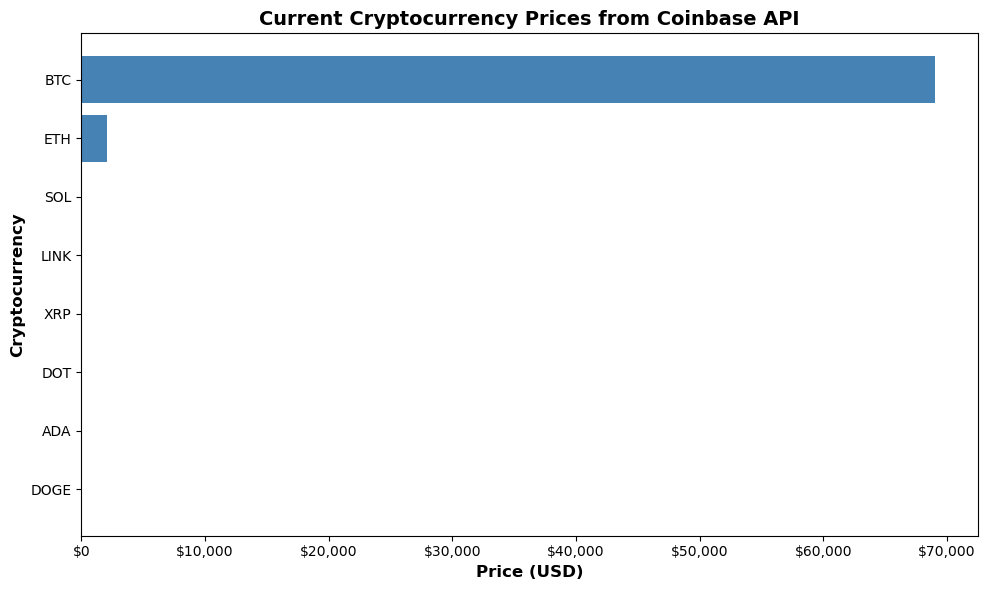

Chart created successfully!


In [6]:
# Create a DataFrame without price formatting for plotting
# We need numeric values for the chart, not strings with dollar signs
df_plotting = pd.DataFrame(coin_data)

# Sort in ascending order (lowest to highest prices)
# This makes horizontal bar charts easier to read
# with the tallest bar at the top
df_plotting = df_plotting.sort_values('Price USD', ascending=True)

# Create a new figure with specific size
# figsize=(10, 6) means 10 inches wide, 6 inches tall
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
# barh() creates horizontal bars, bar() would create vertical ones
# 'steelblue' is a nice blue color for the bars
plt.barh(df_plotting['Symbol'], df_plotting['Price USD'], color='steelblue')

# Add labels and title to the chart
# fontsize controls text size, fontweight='bold' makes text bold
plt.xlabel('Price (USD)', fontsize=12, fontweight='bold')
plt.ylabel('Cryptocurrency', fontsize=12, fontweight='bold')
plt.title('Current Cryptocurrency Prices from Coinbase API', fontsize=14, fontweight='bold')

# Format the x-axis to display as currency with dollar signs
# ax = plt.gca() gets the current axes object
# The lambda function formats each tick label
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Adjust the layout to prevent label cutoff
# tight_layout() automatically adjusts spacing
plt.tight_layout()

# Display the chart
plt.show()

# Print confirmation message
print("Chart created successfully!")

## Summary

You now understand the fundamental pattern that works for almost any public API:

```python
url = "https://api.example.com/endpoint"
response = requests.get(url)
data = response.json()
value = data['key']
```

This same pattern works for almost any public API you encounter!

In [7]:
# Print completion message
print("Lesson complete.")
print()
print("You successfully:")
print("  - Made API calls using Python")
print("  - Parsed JSON responses")
print("  - Built a DataFrame from API data")
print("  - Created a chart from the data")

Lesson complete.

You successfully:
  - Made API calls using Python
  - Parsed JSON responses
  - Built a DataFrame from API data
  - Created a chart from the data
